# Outliers

**Author:** Tohidul Islam Tareq

Detecting outliers and comparing ordinary least squares with robust regression.

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 4)


In [5]:
from sklearn.linear_model import LinearRegression, HuberRegressor

rng = np.random.default_rng(RANDOM_STATE)
X = rng.uniform(0, 10, 80).reshape(-1, 1)
y = 3.0*X.ravel() + 5 + rng.normal(0, 2, 80)
y[:6] += np.array([35, -30, 25, -25, 30, -35])

df = pd.DataFrame({'feature': X.ravel(), 'target': y})
q1, q3 = df['target'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
df['is_outlier'] = ~df['target'].between(lower, upper)
df.head()


,feature,target,is_outlier
0,7.739560,64.469862,True
1,4.388784,-12.452340,True
2,8.585979,56.671488,True
3,6.973680,-0.402811,False
4,0.941773,37.099213,False


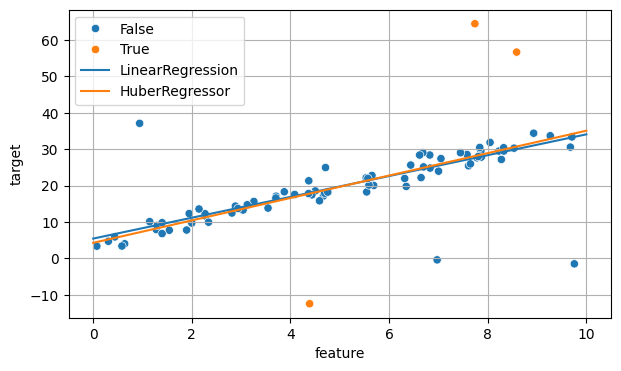

In [6]:
ols = LinearRegression().fit(X, y)
huber = HuberRegressor().fit(X, y)
grid = np.linspace(0, 10, 100).reshape(-1, 1)

plt.figure()
sns.scatterplot(data=df, x='feature', y='target', hue='is_outlier')
plt.plot(grid, ols.predict(grid), label='LinearRegression')
plt.plot(grid, huber.predict(grid), label='HuberRegressor')
plt.legend(); plt.grid(True); plt.show()
